# Zgomot. Operatii pe vecinatate. Masuri de calitate

Operatiile pe vecinatate presupun ca noua valoarea a unui pixel depinde atat de valoarea originala a acestuia, cat si de valorile pixelilor din jur, asa cum sunt definite de vecinatatea (fereastra de filtrare).

Operatiile de filtrare se pot imparti in doua mari categorii:
 - Filtrarea liniara: se aplica un operator liniar asupra vecinatatii. Valoarea noua a pixelului este deci o combinatie liniara (o suma ponderata) a pixelilor din jurul pixelului curent;
 - Filtrarea neliniara: operatia aplicata asupra vecinatatii este neliniara. Un exemplu tipic de filtru neliniar este filtrul de ordine, care ordoneaza valorile din vecinatate, iar valoarea noua a pixelului este una din valorile din sirul ordonat (poate fi maxim, minim, medianul, etc.).
 
Reamintim ca, spre deosebire de filtrarea imaginilor cu niveluri de gri, imaginile color permit mai multe abordari, in ceea ce priveste filtrarea:
 - Filtrarea marginala, in care prelucram fiecare plan de culoare RGB independent de celelalte;
 - Filtrare bazata pe schimbarea spatiului de culoare, prelucrarea planului de luminanta (sau echivalentul acestuia) si transformarea inapoi in RGB;
 - Filtrarea vectoriala care presupune ca fiecare pixel este descris de un triplet, iar prelucrarea este realizata intr-un spatiu tridimensional.
 
## 1. Filtrarea liniara
Dupa cum a fost explicat anterior, filtrarea liniara presupune aplicarea unui operator liniar asupra vecinatatii pixelului, rezultand intr-o combinatie liniara / suma ponderata  de tipul $\alpha_1\cdot I(i_1,j_1)+\alpha_2\cdot I(i_2,j_2)+...$. Modul in care este se aplica filtrarea liniara din punct de vedere practic este urmatorul:
 - Se defineste vecinatatea (cati pixeli inconjuratori alegem). Se prefera alegerea ferestrelor cu numar impar de pixel, astfel incat pixelul central sa aiba un numar egal de vecini in stanga si dreapta, respectiv sus si jos;
 - Se defineste filtrul (denumit si masca), ca o matrice de ponderi.
 - Masca se "gliseaza" de-a lungul imaginii. Se inmulteste fiecare pixel din vecinatate cu ponderea corespunzatoare din masca. Valoarea pixelului final este suma acestor produse.
$$Iesire(i,j) = \mathop{\sum\sum}_{(m,n)\epsilon V} Masca(m,n)\cdot Intrare(i-m,j-n)$$
<center> Definirea filtrarii liniare ca o convolutie</center>

In functie de valorile din masca, putem defini filtre:
 - De mediere, in care rezultatul este media aritmetica sau orice alta medie ponderata a valorilor din vecinatate. In acest caz, suma ponderilor trebuie sa fie <b>1</b>. Daca toate ponderile sunt egale, atunci rezulta media aritmetica;
 - De contrastare, in care se extrag contururi. Aceste filtre au suma ponderilor <b>0</b> (numite si filtre de tip <i>Laplacian</i>. Daca imaginea rezultata este adaugata imaginii originale (si normalizata), atunci se va obtine o imagine care are contururile accentuate.
 <br><br>
<center>
 \begin{bmatrix}
 \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
 \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\
 \frac{1}{9} & \frac{1}{9} & \frac{1}{9}
 \end{bmatrix} 
 </center><br>
 </center>
 \begin{bmatrix}
 -\frac{1}{8} & -\frac{1}{8} & -\frac{1}{8}\\
 -\frac{1}{8} & 1 & -\frac{1}{8}\\
 -\frac{1}{8} & -\frac{1}{8} & -\frac{1}{8}\end{bmatrix}</center><br>
<center> Filtrul de medie aritmetica (sus) si filtrul Laplacian (jos)</center>

## 2. Filtrarea neliniara de ordine
In anumite cazuri, nu este de dorit ca rezultatul final sa fie o combinatie liniara a valorilor din vecinatate. In acest caz se utilizeaza filtre neliniare, in care rezultatul nu este o functie liniara aplicata pixelilor de la intrare. Un exemplu de filtru neliniar folosit in practica sunt filtrele de ordine, care aleg valoarea de iesire din sirul ordonat al valorilor din vecinatate. Functionarea unui filtru de ordine (rank filter):
 - Se ordoneaza crescator pixelii din vecinatate;
 - Se alege pixelul de pe pozitia dorita (primul pentru filtru de minim, ultimul pentru filtru de maxim, <b>cel din mijloc pentru filtrul median</b>);
 - Valoarea pixelului curent din imaginea de iesire este valoarea aleasa din pasul anterior.


## 3. Zgomotului din imagine
O problema clasica in prelucrarea imaginilor este reprezentata de reducerea zgomotului. Cele mai frecvente tipuri de zgomot sunt:
 - Zgomotul aditiv cu distributie simetrica (uzual Gaussiana);
 - Zgomotul impulsiv, cand valoarea pixelului este cu totul diferita fata de cea care ar fi trebuit sa apara in imagine (valori extreme de 0 sau 255).

Solutiile clasice pentru reducerea zgomotului constau in folosirea de filtre. <b>Pentru reducerea zgomotului Gaussian se foloseste filtrul de mediere, iar pentru zgomotul impulsiv se foloseste filtrul median.</b>


## 4. Masurarea calitatii fata de o referinta
Eroarea se masoara in fiecare pixel si se mediaza pe imagine. Eroarea este o functie de diferenta imaginii date fata de imaginea de referinta.
Eroarea poate fi absoluta, patratica, etc.
Eroarea se poate normaliza la valorile imaginii (devenind o eroare relativa).

## <font color=red>Atentie:
 - Daca vreti sa faceti o copie a unei imagini, folositi o constructie de tipul ```imagine_2 = imagine_1.copy()```. Daca scrieti direct ```imagine_2 = imagine_1```, se va crea o referinta (pointer) catre imaginea originala, si ce modificati in imaginea a doua se va modifica si in imaginea originala;
 - Pana acum s-a folosit functia ```plt.figure()```. Pentru a vedea mai mare imaginile folositi ```plt.figure(figsize=(M,N))``` (numerele <i>M</i> si <i>N</i> sunt dimensiunile in inch ale figurii afisate).</font>
 - Atentie la gama de valori si tipul de valori pentru imaginile prelucrate

### Exercitiul 1. Construiti o functie care are intrare imaginea, adauga zgomot Gaussian (de medie 0) si apoi returneaza imaginea zgomotoasa. Vizualizati rezultatul aplicarii acestei functii. Incercati mai multe valori ale dispersiei distributiei, si observati cum este afectata imaginea. 
Reamintim, pentru crearea unei functii in Python se utilizeaza urmatoarea sintaxa:
```python
def nume_functie(argumente):
    instructiuni
    return val1, val2, etc.
```
Tot ce se scrie in afara functiei va fi executat ca un script.
Functia pentru generarea unei distributii Gaussiene de o anumita forma:
```python
zg = np.random.normal(medie,dispersie,[nr_linii,nr_coloane,nr_canale])
```

512 512 3


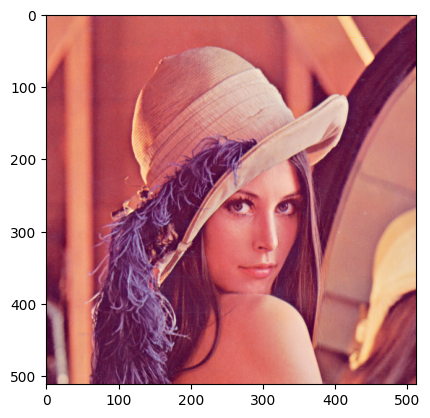

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


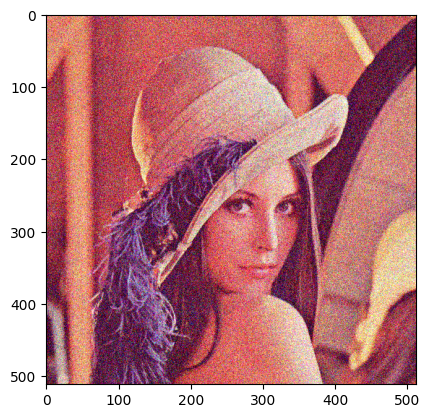

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io,color

img = io.imread('lena.png')
[L,C, pl] = np.shape(img)
print(L,C, pl)

plt.figure(), plt.imshow(img), plt.show();

# generam zgomot gaussian de medie 0: pentru fiecare element din matrice adaugam o valoare de zgomot
# zg = np.random.normal(0,1,[L,C, pl])
# normal - gaussian

# ce fel de valori sunt alea scoase dintr-o distributie gaussiana/normala de medie 0? float
# plt.figure(), plt.imshow(zg), plt.show(); # atunci daca eu vreau sa le afisez cu imshow trebuie sa fie intre 0 si 1
# zg = np.random.normal(0,1.0/6.0,[L,C, pl]) 
# plt.figure(), plt.imshow(zg+0.5), plt.show(); 

zg = np.random.normal(0,0.15,[L,C, pl])
imgzg = img/255.0 + zg

plt.figure(), plt.imshow(imgzg), plt.show(); 
# primi eroare din cauza ca mai sunt 0.03% (+- 3 sigma in jurul mediei)

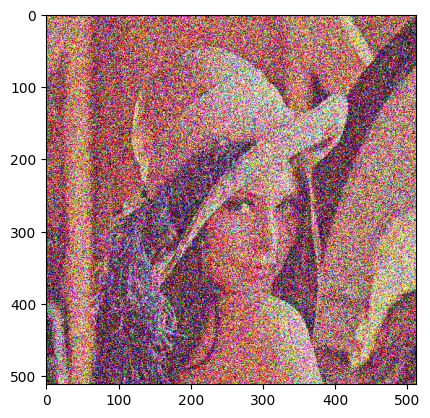

In [5]:
# in functie
def add_Gaussian_noise(img, disp):
    zg = np.random.normal(0, disp, np.shape(img))
    imgzg = img + zg
    return imgzg # mai mici decat 0 sau mai mari decat 1 - nu e bine, ce fac?
# var1: nu fac nimic, dar nu e bine
# var2: accept ca pot sa iasa valori din gama normala si fac un clip: ce e mai mic decat 0 = 0, ce e mai mare decat 1 = 1

def add_Gaussian_noise(img, disp):
    zg = np.random.normal(0, disp, np.shape(img))
    imgzg = np.clip(img + zg, a_min=0, a_max=1)
    return imgzg 

# standardizam functia:
def add_Gaussian_noise(img, disp):
    if np.max(img) > 1: # inseamna ca e uint8 si convertim in float (normalizare la (0, 1))
        img = img / 255.0
    zg = np.random.normal(0, disp, np.shape(img))
    imgzg = np.clip(img + zg, a_min=0, a_max=1)
    return imgzg 

imgzg = add_Gaussian_noise(img,0.5)
plt.figure(), plt.imshow(imgzg), plt.show(); 


### Exercitiul 2. Construiti o alta functie care sa afecteze o imagine cu zgomot impulsiv si vizualizati rezultatul. Afectati 10% din pixelii din fiecare plan de culoare al imaginii. Pixelii afectati au fie valoarea 0, fie 255. Vizualizati rezultatul aplicarii acestei functii. Incercati mai multe valori ale dispersiei distributiei, si observati cum este afectata imaginea. 

Cel mai probabil veti avea nevoie de o functie care sa va genereze aleator numere intregi (pentru a decide locatiile care vor fi afectate de zgomot):
```python
numere_intregi = np.random.randint(valoare_minima,valoare_maxima_exclusiva,[dimensiunea_1,dimensiunea_2,...])
```
Aceasta functie genereaza numere intregi in intervalul <b>[valoare_minima,valoare_maxima)</b>

In [24]:
def add_impulsive_noise(img, p0, p1):
    if np.max(img) > 1:  # inseamna ca e uint8 si convertim in float (normalizare la (0, 1))
        img = img / 255.0
    [L, C, pl] = np.shape(img)
    nrPix0 = int(L * C * p0)
    nrPix1 = int(L * C * p1)

    for plan_curent in range(0, 3):
        numere_intregiL = np.random.randint(0, L, [nrPix0])  # (valoare_minima,valoare_maxima_exclusiva,[dimensiunea_1,dimensiunea_2,...])
        numere_intregiC = np.random.randint(0, C, [nrPix0])  # (valoare_minima,valoare_maxima_exclusiva,[dimensiunea_1,dimensiunea_2,...])
        img[numere_intregiL, numere_intregiC, plan_curent] = 0
        numere_intregiL = np.random.randint(0, L, [nrPix1])
        numere_intregiC = np.random.randint(0, C, [nrPix1])
        img[numere_intregiL, numere_intregiC, plan_curent] = 1
    
    return img

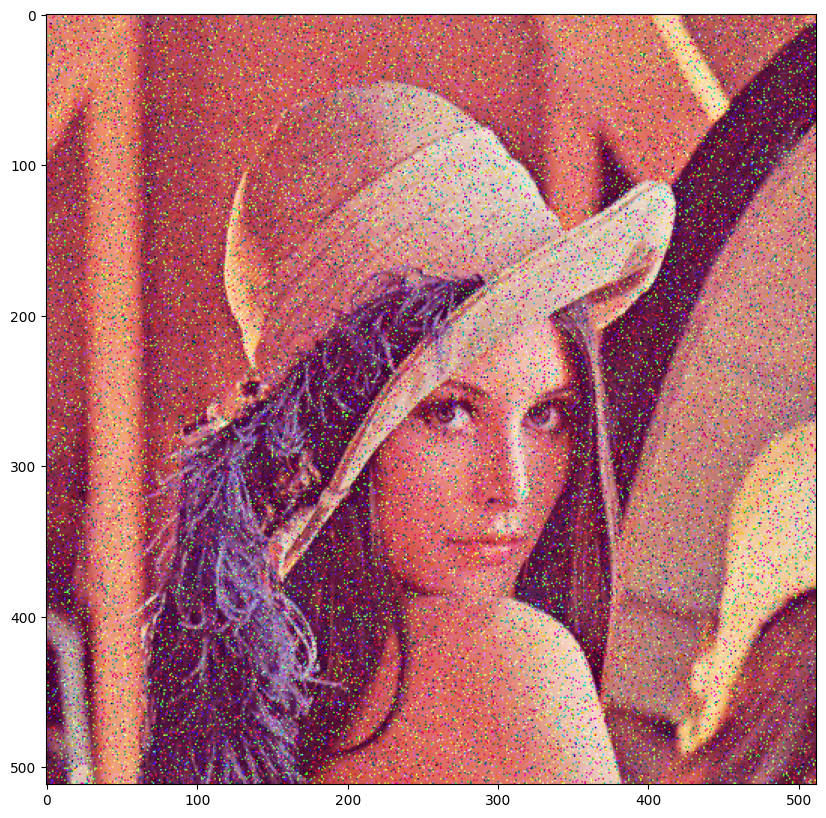

In [25]:
imgzg_imp = add_impulsive_noise(img, 0.05, 0.05)
plt.figure(figsize=(10, 10)), plt.imshow(imgzg_imp), plt.show(); 

### Exercitiul 3. Construiti o functie care sa calculeze masuri de calitate (normalizate si nenormalizate) ale unei imagini in raport cu o imagine de referinta. Verificati masurile de calitate pentru imaginile zgomotoase create anterior

In [29]:
def mse(img0, img): # img0 e imagiena de referinta
    MSE = np.sum((img-img0)**2) / np.prod(np.shape(img)) # **2 = la patrat
    return MSE # cand nu merge? cand rezultatul difera de float. daca se intampla sa scad uint8 din uint8

def mse(img0, img): # img0 e imagiena de referinta
    if np.max(img) > 1:
        img = img / 255.0
    if np.max(img0) > 1:
        img0 = img0 / 255.0
    MSE = np.sum((img-img0)**2) / np.prod(np.shape(img))
    sumval = np.sum(img0**2) / np.prod(np.shape(img))
    NMSE = MSE / sumval
    return MSE, NMSE

In [30]:
MSE, NMSE = mse(img,imgzg_imp)
print(MSE, NMSE)

0.028976212926481112 0.09457968300617825


### Exercitiul 4. Folosind functia definita la ex.1, adaugati zgomot Gaussian unei imagini si filtrati <i>marginal</i> imaginea cu un filtru de mediere. Ce observati la imaginea de iesire? Incercati cu alte dimensiuni ale mastii. Masurati calitatea cu functia definita la ex.3.

In [35]:
from scipy import signal


# imgzg_imp img zu zgomot
# img - img de referinta

def filtrare_liniara(img, nucleu):
    if np.max(img) > 1:
        img = img / 255.0
    nucleu = nucleu / np.sum(nucleu)
    [d1, d2] = np.shape(nucleu)
    W = d1//2
    
    kernel = np.zeros((2*W+1, 2*W+1))
    kernel[W, W] = 1
    [L,C, nrplane] = np.shape(img)
    imgout = np.zeros(np.shape(img))
    
    for pl in range(0, 3):
        imgout[:,:,pl] = signal.convolve2d(img[:,:,pl], nucleu, mode='same', boundary='symm') # e la fel pt ca face bordarea implicit
                
    return imgout

def mediere_aritmetica(img, dim_fereastra):
    h, w, c = img.shape
    img_out = np.zeros_like(img, dtype=np.uint8)
    offset = dim_fereastra // 2
    for y in range(offset, h - offset):
        for x in range(offset, w - offset):
            for channel in range(c):
                patch = img[y - offset:y + offset + 1, x - offset:x + offset + 1, channel]
                img_out[y, x, channel] = np.mean(patch)
    return img_out

def median_filter(img, dim_fereastra):
    h, w, c = img.shape
    img_out = np.zeros_like(img, dtype=np.uint8)
    offset = dim_fereastra // 2
    for y in range(offset, h - offset):
        for x in range(offset, w - offset):
            for channel in range(c):
                patch = img[y - offset:y + offset + 1, x - offset:x + offset + 1, channel]
                img_out[y, x, channel] = np.median(patch)
    return img_out

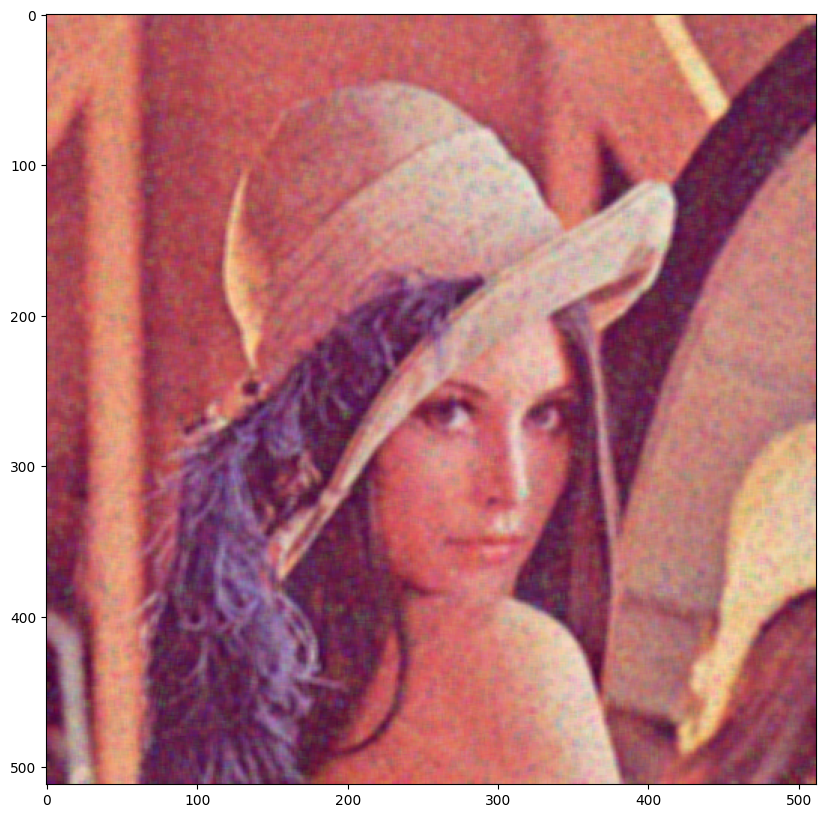

In [40]:
imgfiltrat = filtrare_liniara(imgzg_imp, np.ones((5, 5)) / 25.0)
plt.figure(figsize=(10, 10)), plt.imshow(imgfiltrat), plt.show(); 

img = io.imread('lena.png')



### Exercitiul 5. Folosind functia definita la ex.2 si o imagine la alegere, creeati o imagine afectata de zgomot impulsiv. Utilizati filtrul median <i>marginal</i> pentru reducerea zgomotului. Cum arata imaginea de iesire? Incercati sa utilizati filtrul median marginal si pentru zgomot Gaussian. Masurati calitatea cu functia definita la ex.3.
Pentru a sorta crescator o matrice puteti folosi functia ```np.sort()```:
```vector_sortat = np.sort(vector)```
Daca aveti de-a face cu o matrice insa, functia ```np.sort()``` va sorta fiecare linie individual. Pentru a solutiona aceasta problema, aveti doua solutii:
 - Transformati mai intai matricea in vector cu ```vector = matrice.flatten()```;
 - Mentionati ca nu vreti de-a lungul vreunei axe anume sortarea ```vector = np.sort(matrice,axis=None)```

### Exercitiul 6. Aplicati filtrul de contrastare pe o imagine la alegere si afisati rezultatul (fiecare plan de culoare independent). Adaugati rezultatul imaginii originale si afisati.